In [13]:
from sklearn.cluster import KMeans
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, ConcatDataset
from src.models import SignalFeatureCNN1D
from src.analysis import clustering, plot_clusters
from utils import load_yaml
from src.data_processing import PtDataset

In [14]:
# Define triplet loss
class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(TripletLoss, self).__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        # Calculate distances
        pos_dist = F.pairwise_distance(anchor, positive, p=2)
        neg_dist = F.pairwise_distance(anchor, negative, p=2)
        # Triplet loss formula
        loss = F.relu(pos_dist - neg_dist + self.margin)
        return loss.mean()

# Step 2: K-means clustering algorithm
def apply_kmeans(features, n_clusters):
    kmeans = KMeans(n_clusters=n_clusters, n_init='auto', random_state=42)
    kmeans.fit(features)
    return kmeans

# Step 3: Adjust with unlabeled data and KL-divergence
def kl_divergence_loss(unlabeled_features, cluster_centers):
    distances = torch.cdist(unlabeled_features, cluster_centers, p=2)
    soft_assignments = F.softmax(-distances, dim=1)
    hard_assignments = torch.argmax(soft_assignments, dim=1)
    loss = 0
    for i in range(len(cluster_centers)):
        assigned_points = unlabeled_features[hard_assignments == i]
        if len(assigned_points) > 0:
            mean_point = torch.mean(assigned_points, dim=0)
            loss += F.kl_div(mean_point.log(), cluster_centers[i], reduction='batchmean')
    return loss

In [35]:
dataset_name = "CWRU"
sample_size = 120000

data_filter = load_yaml('config/filters_config.yaml')[dataset_name]
dataset = PtDataset(data_filter, sample_size, apply_augmentation=False)
dataset_da = PtDataset(data_filter, sample_size, apply_augmentation=True)
data_loader = DataLoader(dataset, batch_size=32, shuffle=True)
data_loader_da = DataLoader(dataset_da, batch_size=32, shuffle=True)
concat_dataset = ConcatDataset([dataset, dataset_da])
concat_dataloader = DataLoader(concat_dataset, batch_size=32, shuffle=True)

In [11]:
# Parameters
segment_length = 540
label_mapping = {"N": 0, "I": 1, "O": 2, "B": 3}
n_class = len(label_mapping)
n_epochs = 50

In [ ]:
# Initialize model, optimizers, and losses
model = SignalFeatureCNN1D()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
cross_entropy_loss = nn.CrossEntropyLoss()
triplet_loss_fn = TripletLoss(margin=1.0)

# Training loop
for epoch in range(n_epochs):  # Number of epochs
    total_loss = 0
    for batch_data, batch_labels in concat_dataloader:

        # Forward pass
        features, outputs = model(batch_data)

        # Cross-entropy loss
        ce_loss = cross_entropy_loss(outputs, batch_labels)

        # Triplet loss
        anchor = features[::3]  # Every third example as anchor
        positive = features[1::3]  # Every third example + 1 as positive
        negative = features[2::3]  # Every third example + 2 as negative

        # Ensure the triplet sizes match
        min_triplet_size = min(len(anchor), len(positive), len(negative))
        anchor = anchor[:min_triplet_size]
        positive = positive[:min_triplet_size]
        negative = negative[:min_triplet_size]

        triplet_loss = triplet_loss_fn(anchor, positive, negative)

        # Combine losses
        loss = ce_loss + triplet_loss

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch + 1}, Total Loss: {total_loss:.4f}")

# Saving model
torch.save(model.state_dict(), 'model_concat.pth')    


Epoch 1, Total Loss: 13.4873
Epoch 2, Total Loss: 42.7968
Epoch 3, Total Loss: 16.2090
Epoch 4, Total Loss: 29.2298
Epoch 5, Total Loss: 29.3379
Epoch 6, Total Loss: 26.6674
Epoch 7, Total Loss: 26.9594
Epoch 8, Total Loss: 19.1298
Epoch 9, Total Loss: 22.2440
Epoch 10, Total Loss: 4.9436
Epoch 11, Total Loss: 11.5857
Epoch 12, Total Loss: 20.1265
Epoch 13, Total Loss: 20.3166
Epoch 14, Total Loss: 10.4863
Epoch 15, Total Loss: 8.8216
Epoch 16, Total Loss: 12.5744
Epoch 17, Total Loss: 14.1134
Epoch 18, Total Loss: 8.4371
Epoch 19, Total Loss: 8.0913
Epoch 20, Total Loss: 5.3440
Epoch 21, Total Loss: 9.7199
Epoch 22, Total Loss: 10.8992
Epoch 23, Total Loss: 9.5942
Epoch 24, Total Loss: 6.6936
Epoch 25, Total Loss: 3.4765
Epoch 26, Total Loss: 5.6706
Epoch 27, Total Loss: 6.6831
Epoch 28, Total Loss: 7.6369
Epoch 29, Total Loss: 4.8243
Epoch 30, Total Loss: 3.1136
Epoch 31, Total Loss: 4.9649
Epoch 32, Total Loss: 6.3395
Epoch 33, Total Loss: 3.9762
Epoch 34, Total Loss: 3.5130
Epoch 3

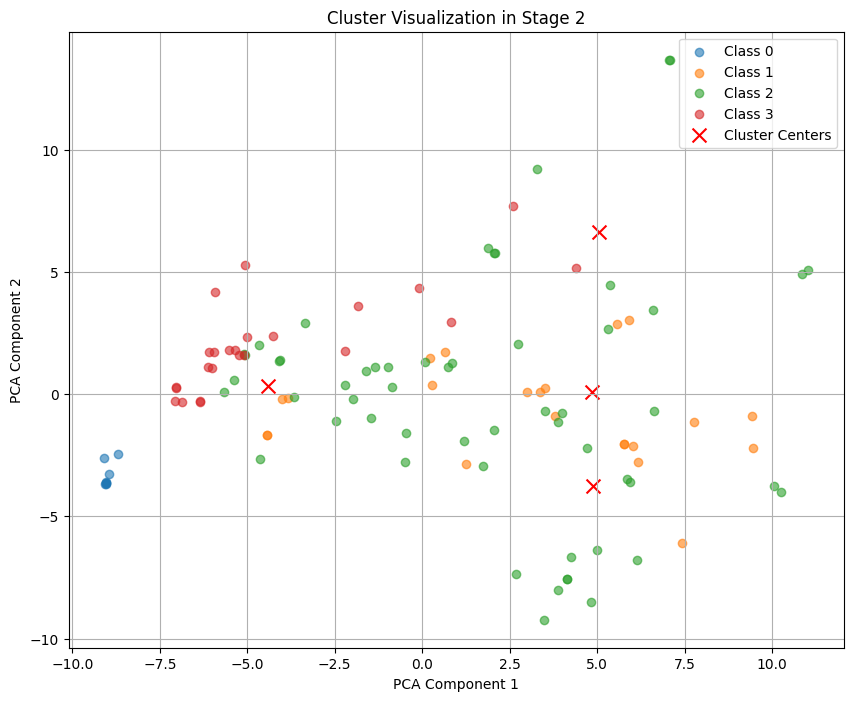

In [34]:
# Load the model
model = SignalFeatureCNN1D()
model.load_state_dict(torch.load('model_da.pth', weights_only=True))
model.eval()

# Clustering
concat_dataset = ConcatDataset([dataset, dataset_da])
concat_dataloader = DataLoader(concat_dataset, batch_size=32, shuffle=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
n_clusters = n_class
cluster_centers, features, labels = clustering(model, concat_dataloader, n_clusters, device=device)
plot_clusters(features, labels, cluster_centers, n_clusters)

Validation Loss: 0.3134
Validation Accuracy: 0.8909


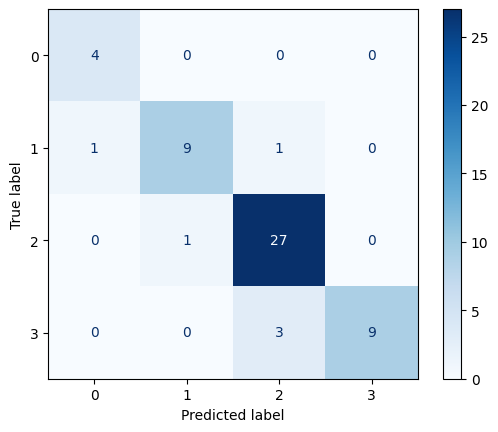

In [30]:
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score  # Exemplo para classificação

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# Suponha que você tenha um conjunto de dados de validação
validation_dataset = dataset
validation_loader = DataLoader(validation_dataset, batch_size=32, shuffle=False)

# Definir a função de perda (por exemplo, para classificação usamos CrossEntropyLoss)
criterion = nn.CrossEntropyLoss()

# Coloca o modelo em modo de avaliação
model = SignalFeatureCNN1D()
model.load_state_dict(torch.load('model_da.pth', weights_only=True))
model.eval()

# Variáveis para armazenar perdas e previsões
validation_loss = 0.0
all_labels = []
all_preds = []

# Desativa a autograd para economizar memória e melhorar a velocidade
with torch.no_grad():
    for data in validation_loader:
        inputs, labels = data
        features, outputs = model(inputs)
        loss = criterion(outputs, labels)  # Define sua função de perda
        
        validation_loss += loss.item() * inputs.size(0)
        
        _, preds = torch.max(outputs, 1)  # Para problemas de classificação
        all_labels.extend(labels.numpy())
        all_preds.extend(preds.numpy())

# Calcula a perda média
validation_loss = validation_loss / len(validation_loader.dataset)

# Calcula a acurácia
accuracy = accuracy_score(all_labels, all_preds)

print(f'Validation Loss: {validation_loss:.4f}')
print(f'Validation Accuracy: {accuracy:.4f}')

# Calcula a matriz de confusão
conf_matrix = confusion_matrix(all_labels, all_preds)

# Exibir a matriz de confusão usando matplotlib
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
disp.plot(cmap=plt.cm.Blues)
plt.show()
